<a href="https://colab.research.google.com/github/yulivvv/toxic-text-classifier-ru/blob/main/toxic_text_classifier_ru_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: Бинарная классификация токсичности текстов

## Практический кейс

Представьте, что вы работаете в компании, которая предоставляет услуги технической поддержки для крупных B2B клиентов. Ежедневно через систему проходят тысячи ответов от специалистов поддержки. Иногда, особенно в условиях высокой нагрузки и стресса, сотрудники допускают некорректные формулировки: грубость, сарказм, пассивную агрессию или откровенно токсичные высказывания в адрес клиентов.

Такие инциденты несут прямые репутационные потери для бизнеса. Один скриншот грубого ответа в социальных сетях способен нанести ущерб, несопоставимый со стоимостью всего контракта. Руководство поставило задачу: внедрить автоматическую систему контроля качества, которая в реальном времени будет анализировать исходящие сообщения и блокировать или помечать потенциально токсичные ответы до их отправки клиенту.

Ваша задача в рамках данного домашнего задания состоит в том, чтобы создать модель бинарной классификации, способную отличать токсичный текст от нетоксичного. Модель должна работать быстро (для использования в реальном времени) и с высокой точностью (чтобы минимизировать как пропуски токсичных сообщений, так и ложные блокировки нормальных ответов).

## Рекомендации по выполнению в Google Colab

Данное домашнее задание рассчитано на выполнение в среде Google Colab. Ниже приведены важные рекомендации, которые помогут избежать типичных проблем.

**Выбор среды выполнения.** Перед началом работы переключите Runtime на GPU. Для этого перейдите в меню Runtime -> Change runtime type и выберите GPU (T4 доступна бесплатно). Без GPU дообучение модели займет неприемлемо долгое время.

**Если не хватает видеопамяти (CUDA Out of Memory).** Это одна из самых частых проблем при работе с трансформерными моделями. Вот что можно предпринять:

1. Уменьшите BATCH_SIZE. Начните с 64 или даже 32 вместо 128. Это самый простой и эффективный способ снизить потребление VRAM.
2. Уменьшите INPUT_MAX_TOKENS. Вместо 128 попробуйте 64. Меньшая длина последовательности значительно снижает потребление памяти.
3. Уменьшите размер датасета через параметр MAX_DATASET_LEN. Меньше данных означает меньше батчей и меньше нагрузки на память.
4. Используйте меньшую модель. Вместо large-версии модели попробуйте base-версию той же архитектуры.
5. Перезапустите Runtime. Иногда память остается занятой от предыдущих запусков. Перейдите в Runtime -> Restart runtime.
6. Используйте `torch.cuda.empty_cache()` и `gc.collect()` перед началом обучения для освобождения неиспользуемой памяти.

**Сохранение промежуточных результатов.** Colab может отключить сессию при длительном бездействии. Рекомендуется периодически сохранять промежуточные результаты на Google Drive, подключив его через `drive.mount('/content/drive')`.

**Установка зависимостей.** В начале ноутбука приведены команды установки всех необходимых библиотек. Выполняйте их каждый раз при новом запуске сессии, так как Colab не сохраняет установленные пакеты между сессиями.

## Распределение баллов

| Блок | Задание | Баллы |
|------|---------|-------|
| 0 | Формализация задачи | 5 |
| 1 | Сбор данных (положительный класс) | 5 |
| 2 | Очистка датасета | 5 |
| 3 | Разделение на подвыборки и балансировка | 5 |
| 4 | Количественная оценка и визуализация датасета | 5 |
| 5 | Публикация датасета на Hugging Face | 5 |
| 6 | Дообучение модели (код предоставлен) | 0 |
| 7 | Оценка модели и визуализация ошибок | 10 |
| 8 | Ручной инференс и замер времени GPU vs CPU | 5 |
| 9 | Публикация модели на Hugging Face | 5 |
| **Итого** | | **50** |

---

## Блок 0. Формализация задачи (5 баллов)

### 0.1 Формулировка бизнес-задачи

Опишите бизнес-задачу своими словами. Какую проблему мы решаем? Какие последствия несет нерешенная проблема для бизнеса? Какой результат ожидает заказчик?


In [2]:
# Ваш ответ (в виде текста в markdown-ячейке выше или в комментариях здесь):
# ...


Компания хочет автоматически контролировать качество сообщений, отправляемых сотрудниками технической поддержки клиентам.

Основная задача — обнаруживать токсичные, грубые, оскорбительные или агрессивные сообщения до их отправки клиенту и предупреждать оператора или блокировать отправку.

Если такая система отсутствует, компания может столкнуться с серьезными репутационными потерями, жалобами клиентов, снижением доверия, расторжением контрактов и финансовыми убытками.

Ожидаемый результат — модель машинного обучения, которая в режиме реального времени определяет, является ли сообщение токсичным, и делает это быстро и с высокой точностью.

### 0.2 Сведение к ML-задаче

Заполните следующие пункты:


In [3]:
# Тип задачи:Бинарная классификация текста.
# Объект классификации:Текст сообщения сотрудника технической поддержки.
# Класс 1 (токсичный):Сообщения, содержащие оскорбления, грубость, агрессию, угрозы, унижения, токсичное или неуважительное общение.
# Класс 0 (нетоксичный):Корректные, нейтральные и вежливые сообщения без признаков токсичности.
# Целевая переменная:label (0 — нетоксичный текст, 1 — токсичный текст).


### 0.3 Выбор ML-метрик

Обоснуйте выбор метрик для оценки качества модели. Подумайте: что важнее в данном бизнес-кейсе, Precision или Recall? Почему? Какие метрики вы будете использовать и зачем?


In [4]:
# Основная метрика:Recall

# Дополнительные метрики:Precision, F1-score, Accuracy, ROC-AUC

# Обоснование:

# В данном бизнес-кейсе наиболее важно обнаружить как можно больше токсичных сообщений,
# поэтому приоритетной является метрика Recall. Пропуск токсичного сообщения может привести
# к серьезным репутационным потерям компании.

# При этом слишком большое количество ложных срабатываний также нежелательно, поскольку
# оно будет мешать работе сотрудников поддержки. Поэтому дополнительно оцениваются
# Precision и F1-score, которая позволяет найти баланс между Precision и Recall.

# Accuracy используется как общая характеристика качества модели, а ROC-AUC показывает
# способность модели разделять токсичные и нетоксичные сообщения независимо от выбранного порога классификации.



---

## Блок 1. Сбор данных (5 баллов)

### 1.1 Установка зависимостей


In [1]:
!pip install -q pytorch-lightning transformers datasets torchmetrics huggingface_hub scikit-learn matplotlib seaborn pandas numpy


### 1.2 Импорт библиотек


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')


### 1.3 Загрузка токсичного класса (Класс 1) — код заполнен

Ниже приведен код загрузки данных для токсичного класса. Эти данные уже подготовлены и не требуют модификации с вашей стороны. Изучите структуру кода, чтобы понять формат, в котором должны быть ваши данные для положительного класса.


In [3]:
!pip install -q pyarrow datasets

In [4]:
from datasets import load_dataset
import pandas as pd

df = pd.DataFrame(columns=["text", "label"])

dataset = load_dataset("Mnwa/russian-toxic", split="train")

toxic_df = dataset.to_pandas()

toxic_df = toxic_df[toxic_df["label"] == 0][["text", "label"]]

MAX_TOXIC = 30000
toxic_df = toxic_df.sample(
    min(MAX_TOXIC, len(toxic_df)),
    random_state=42
)

df = pd.concat([df, toxic_df], ignore_index=True)

print(f"Загружено записей токсичного класса: {len(df)}")
df.sample(5)

Загружено записей токсичного класса: 30000


,text,label
13451,да таких ебанутых много зомбо ящик смотрят а т...,0
25581,сука не известной породы,0
20736,...вот и отправте эту блядюгу к диким арнаутам!!,0
13342,"[id62877234|Сергей], это с хуя ли в друг 😂😂😂😂",0
2963,,0


### 1.4 Загрузка нетоксичного класса (Класс 0) — задание для студента

Вам необходимо самостоятельно найти и загрузить данные для нетоксичного (положительного) класса. Итоговый DataFrame должен содержать колонки `text` и `label` (где label = 0).

**Подсказки по поиску данных:**

- Подумайте, какие тексты гарантированно не содержат токсичности. Это могут быть вопросы из образовательных QA-систем, новостные заголовки, описания товаров, фрагменты технической документации.
- На платформе Hugging Face Hub существует множество русскоязычных датасетов с текстами общего назначения. Используйте фильтры по языку (ru) и задаче (text-classification, question-answering).
- Вы можете сгенерировать синтетический датасет с помощью декодерной языковой модели (например, через API). Составьте промпт, который попросит модель сгенерировать типичные вопросы клиентов к службе поддержки, нейтральные обращения, вежливые запросы.
- Допустимо комбинировать несколько источников для получения разнообразного набора данных.
- Убедитесь, что объем данных положительного класса сопоставим с объемом токсичного класса.


In [5]:
from datasets import load_dataset
import pandas as pd

# Загружаем нетоксичные тексты
dataset = load_dataset("SetFit/amazon_massive_intent_ru-RU", split="train")

neutral_df = dataset.to_pandas()

print(neutral_df.columns)

Index(['id', 'label', 'text', 'label_text', 'label_text_ru'], dtype='object')


In [6]:
neutral_df = neutral_df[["text"]]
neutral_df["label"] = 1

MAX_NEUTRAL = len(df)

neutral_df = neutral_df.sample(
    n=min(MAX_NEUTRAL, len(neutral_df)),
    random_state=42
)

df = pd.concat([df, neutral_df], ignore_index=True)

print(f"Итого записей: {len(df)}")
print(df["label"].value_counts())

Итого записей: 41514
label
0    30000
1    11514
Name: count, dtype: int64


---

## Блок 2. Очистка датасета (5 баллов)

Сырые данные практически всегда содержат шум. Ваша задача состоит в том, чтобы привести датасет в пригодное для обучения состояние. Необходимо выполнить следующие шаги:

1. **Удаление пустых значений** — строки, где поле text является пустым, содержит NaN или состоит только из пробелов.
2. **Удаление дубликатов** — точные дубликаты по полю text.
3. **Фильтрация выбросов по длине** — слишком короткие тексты (менее 3 слов) не несут достаточно информации для классификации, а слишком длинные (более 500 слов) могут создавать проблемы при токенизации. Определите разумные пороги и удалите выбросы.


In [7]:
# === ВАШ КОД ЗДЕСЬ ===

# 1. Удаление пустых значений
df = df.dropna(subset=["text"])
df["text"] = df["text"].astype(str)
df = df[df["text"].str.strip() != ""]

# 2. Удаление дубликатов
df = df.drop_duplicates(subset=["text"])

# 3. Фильтрация выбросов по длине
# Считаем количество слов
df["word_count"] = df["text"].str.split().str.len()

# Оставляем тексты от 3 до 500 слов
df = df[(df["word_count"] >= 3) & (df["word_count"] <= 500)]

# Удаляем вспомогательный столбец
df = df.drop(columns=["word_count"])

# Обновляем индексы
df = df.reset_index(drop=True)

# === КОНЕЦ ВАШЕГО КОДА ===

print(f"Записей после очистки: {len(df)}")
print(f"Распределение классов:\n{df['label'].value_counts()}")


Записей после очистки: 37003
Распределение классов:
label
0    26718
1    10285
Name: count, dtype: int64


---

## Блок 3. Разделение на подвыборки и балансировка (5 баллов)

Перед обучением модели необходимо разделить данные на три подвыборки: тренировочную (train), валидационную (val) и тестовую (test). Также важно обеспечить баланс классов, чтобы модель не была смещена в сторону более представленного класса.

**Что нужно сделать:**

1. Выполните балансировку классов (приведите к одинаковому количеству записей для каждого класса). Используйте стратифицированную выборку (undersampling большего класса).
2. Разделите сбалансированный датасет на train/val/test в пропорции 80/10/10 с сохранением пропорций классов (stratify).


In [8]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# === ВАШ КОД ЗДЕСЬ ===

# 1. Балансировка классов (undersampling)

toxic_df = df[df["label"] == 1]
neutral_df = df[df["label"] == 0]

# Определяем размер меньшего класса
min_size = min(len(toxic_df), len(neutral_df))

# Случайно выбираем одинаковое количество записей
toxic_df = toxic_df.sample(n=min_size, random_state=RANDOM_STATE)
neutral_df = neutral_df.sample(n=min_size, random_state=RANDOM_STATE)

# Объединяем и перемешиваем
balanced_df = pd.concat([toxic_df, neutral_df], ignore_index=True)
balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# 2. Разделение на train/val/test

# Сначала отделяем 20% (val + test)
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=balanced_df["label"]
)

# Затем делим оставшиеся 20% пополам
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"]
)

# === КОНЕЦ ВАШЕГО КОДА ===

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"\nРаспределение в train:\n{train_df['label'].value_counts()}")
print(f"\nРаспределение в val:\n{val_df['label'].value_counts()}")
print(f"\nРаспределение в test:\n{test_df['label'].value_counts()}")


Train: 16456, Val: 2057, Test: 2057

Распределение в train:
label
1    8228
0    8228
Name: count, dtype: int64

Распределение в val:
label
1    1029
0    1028
Name: count, dtype: int64

Распределение в test:
label
0    1029
1    1028
Name: count, dtype: int64


---

## Блок 4. Количественная оценка и визуализация датасета (5 баллов)

Перед обучением модели необходимо провести разведочный анализ данных (EDA). Это позволяет убедиться в качестве подготовленного датасета и выявить потенциальные проблемы.

**Что нужно сделать:**

1. Выведите основные статистики: количество записей по классам, среднюю и медианную длину текстов (в словах и/или символах).
2. Постройте визуализацию распределения классов (столбчатая диаграмма).
3. Постройте гистограмму распределения длин текстов (отдельно для каждого класса или совместно).
4. Сделайте вывод о сбалансированности и качестве датасета.


Количество записей по классам:
label
0    10285
1    10285
Name: count, dtype: int64

Средняя длина текста (слов): 13.16
Медианная длина текста (слов): 7.0

Средняя длина текста (символов): 84.4
Медианная длина текста (символов): 44.0


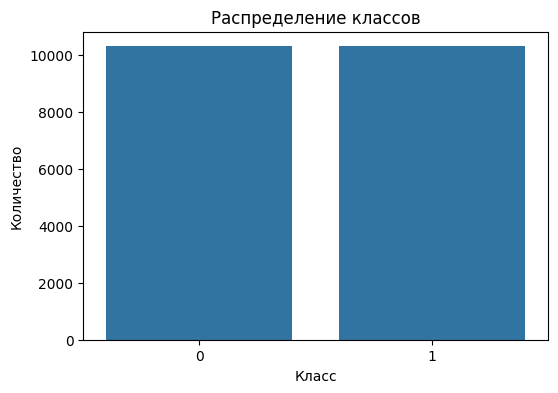

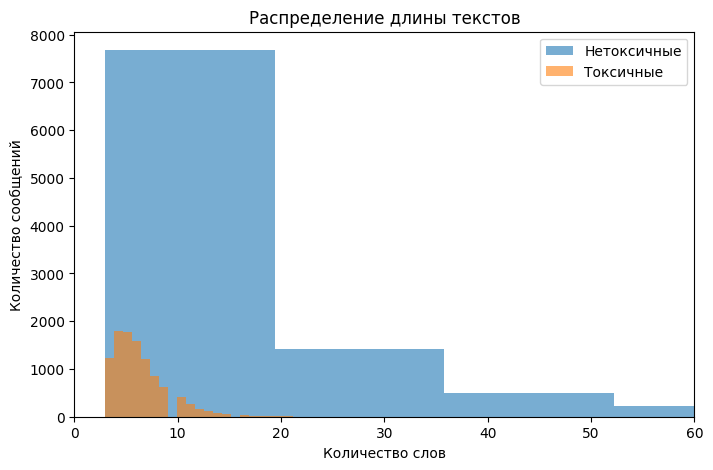

In [9]:
# === ВАШ КОД ЗДЕСЬ ===

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Основные статистики

balanced_df["word_count"] = balanced_df["text"].str.split().str.len()
balanced_df["char_count"] = balanced_df["text"].str.len()

print("Количество записей по классам:")
print(balanced_df["label"].value_counts())

print("\nСредняя длина текста (слов):",
      round(balanced_df["word_count"].mean(), 2))

print("Медианная длина текста (слов):",
      balanced_df["word_count"].median())

print("\nСредняя длина текста (символов):",
      round(balanced_df["char_count"].mean(), 2))

print("Медианная длина текста (символов):",
      balanced_df["char_count"].median())


# 2. Визуализация распределения классов

plt.figure(figsize=(6,4))
sns.countplot(data=balanced_df, x="label")
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.show()


# 3. Гистограмма длин текстов

plt.figure(figsize=(8,5))

plt.hist(
    balanced_df[balanced_df["label"] == 0]["word_count"],
    bins=30,
    alpha=0.6,
    label="Нетоксичные"
)

plt.hist(
    balanced_df[balanced_df["label"] == 1]["word_count"],
    bins=30,
    alpha=0.6,
    label="Токсичные"
)

plt.xlim(0, 60)          # <-- ограничиваем ось X

plt.xlabel("Количество слов")
plt.ylabel("Количество сообщений")
plt.title("Распределение длины текстов")
plt.legend()

plt.show()

# === КОНЕЦ ВАШЕГО КОДА ===


---

## Блок 5. Публикация датасета на Hugging Face (5 баллов)

Опубликуйте подготовленный датасет на платформе Hugging Face Hub. Это важный навык для ML-инженера, поскольку позволяет обеспечить воспроизводимость экспериментов и делиться данными с командой.

**Что нужно сделать:**

1. Авторизуйтесь в Hugging Face Hub.
2. Загрузите датасет (train/val/test splits).
3. Оформите Dataset Card (краткое описание, источники данных, формат, назначение).


In [10]:
from huggingface_hub import login, HfApi
from datasets import Dataset, DatasetDict
from google.colab import userdata

# Авторизация через Colab Secrets
HF_TOKEN = userdata.get("HF_WRITE_TOKEN")

login(token=HF_TOKEN)


# === ВАШ КОД ЗДЕСЬ ===

# 1. Создание DatasetDict из ваших DataFrame

# Убираем старые индексы pandas
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Создаем DatasetDict
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False)
})

# Проверяем структуру
print(dataset)


# 2. Загрузка на Hub

# Замените на свой username Hugging Face
repo_name = "yulivvv/toxic-text-classification-ru"

dataset.push_to_hub(
    repo_name,
    private=False   # True если хотите сделать приватным
)

print("Датасет успешно загружен на Hugging Face!")


# === КОНЕЦ ВАШЕГО КОДА ===


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16456
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2057
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2057
    })
})


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/17 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########|  190kB /  190kB            

README.md:   0%|          | 0.00/3.41k [00:00<?, ?B/s]

Датасет успешно загружен на Hugging Face!


---

## Блок 6. Дообучение модели (код предоставлен, 0 баллов)

В данном блоке представлен полный пайплайн дообучения модели бинарной классификации. Код не требует модификации. Ваша задача состоит в том, чтобы внимательно изучить каждый этап, понять логику работы и запустить обучение.

**Что здесь происходит (объяснение):**

Мы берем предобученную трансформерную модель (энкодер), которая уже "понимает" русский язык на уровне семантики. Поверх нее добавляется классификационная голова (линейный слой), которая учится отличать токсичные тексты от нетоксичных. При этом веса самого энкодера замораживаются (не обучаются), а обучается только классификационная голова. Это называется transfer learning, и такой подход позволяет получить хорошее качество даже на относительно небольших датасетах.

Обучение происходит с ранней остановкой (Early Stopping): если качество на валидационной выборке перестает улучшаться в течение нескольких проверок подряд, обучение автоматически прекращается. Это защищает от переобучения.

### 6.1 Подготовка к обучению


In [11]:
import torch
import gc

print(torch.__version__)
print("Доступна ли Nvidia CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Версия Nvidia CUDA:", torch.version.cuda)
    print("Используемое устройство:", torch.cuda.get_device_properties(0))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


2.11.0+cu128
Доступна ли Nvidia CUDA: True
Версия Nvidia CUDA: 12.8
Используемое устройство: _CudaDeviceProperties(name='Tesla T4', major=7, minor=5, total_memory=14912MB, multi_processor_count=40, uuid=2d7ecd8d-a1d3-2ed4-0f5e-b2b7593b0366, pci_bus_id=0, pci_device_id=4, pci_domain_id=0, L2_cache_size=4MB)


### 6.2 Параметры обучения


In [12]:
# Название предобученной модели из Hugging Face Hub
MODEL_NAME = "ai-forever/ru-en-RoSBERTa"

# Максимальная длина входной последовательности в токенах
INPUT_MAX_TOKENS = 64

# Размер батча (уменьшите, если не хватает видеопамяти)
BATCH_SIZE = 32

# Максимальное количество эпох обучения
MAX_EPOCHS = 3

# Скорость обучения
LR = 2e-4

# Регуляризация весов
WEIGHT_DECAY = 0.01

# Вероятность Dropout (для предотвращения переобучения)
DROPOUT = 0.2

# Как часто проводить валидацию (каждые N шагов)
VAL_CHECK_INTERVAL = 512

# Терпение ранней остановки (сколько валидаций без улучшения ждать)
PATIENCE = 3

# Директория для сохранения модели
MODEL_SAVE_DIR = "./model"


### 6.3 Загрузка токенизатора


In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Токенизатор загружен: {MODEL_NAME}")
print(f"Размер словаря: {tokenizer.vocab_size}")


Токенизатор загружен: ai-forever/ru-en-RoSBERTa
Размер словаря: 98505


### 6.4 Подготовка DataLoader


In [14]:
from torch.utils.data import Dataset as TorchDataset, DataLoader

class TextClassificationDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Создание датасетов
train_dataset = TextClassificationDataset(
    train_df['text'].values, train_df['label'].values, tokenizer, INPUT_MAX_TOKENS
)
val_dataset = TextClassificationDataset(
    val_df['text'].values, val_df['label'].values, tokenizer, INPUT_MAX_TOKENS
)
test_dataset = TextClassificationDataset(
    test_df['text'].values, test_df['label'].values, tokenizer, INPUT_MAX_TOKENS
)

# Создание DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


Train batches: 515, Val batches: 65, Test batches: 65


### 6.5 Модель классификации


In [15]:
import pytorch_lightning as pl
from transformers import AutoModelForSequenceClassification
from torchmetrics import Accuracy, F1Score
from torchmetrics.classification import BinaryMatthewsCorrCoef, BinaryStatScores


class EncoderClassifier(pl.LightningModule):
    def __init__(self, model_name, tokenizer, weight_class_1=1.0, dropout_rate=0.2, lr=2e-4, weight_decay=0.01):
        super().__init__()
        self.save_hyperparameters(ignore=['tokenizer'])

        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=2,
            hidden_dropout_prob=dropout_rate,
            attention_probs_dropout_prob=dropout_rate,
            classifier_dropout=dropout_rate,
            return_dict=True
        )
        self.tokenizer = tokenizer
        self.class_weights = torch.tensor([1.0, weight_class_1])
        self.lr = lr
        self.weight_decay = weight_decay

        # Метрики
        self.train_accuracy = Accuracy(task='binary')
        self.train_f1 = F1Score(task='binary')
        self.val_accuracy = Accuracy(task='binary')
        self.val_f1 = F1Score(task='binary')
        self.train_mcc = BinaryMatthewsCorrCoef()
        self.val_mcc = BinaryMatthewsCorrCoef()
        self.train_stat_scores = BinaryStatScores()
        self.val_stat_scores = BinaryStatScores()
        self.validation_count = 0

        # Замораживаем все слои кроме классификатора
        for name, param in self.model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

        print(f"Модель: {model_name}")
        print(f"Обучаемые параметры:")
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                print(f"  {name}")

    def forward(self, input_ids, attention_mask, labels=None):
        return self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

    def training_step(self, batch, batch_idx):
        outputs = self.forward(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels']
        )
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(self.device))
        loss = loss_fct(logits.view(-1, 2), batch['labels'].view(-1))

        if batch_idx % 50 == 0:
            current_lr = self.trainer.optimizers[0].param_groups[0]['lr']
            print(f"Шаг {self.global_step}: Loss = {loss.item():.6f}, LR = {current_lr:.6f}")

        with torch.no_grad():
            pred_labels = torch.argmax(logits, dim=1).float()
            true_labels = batch['labels'].int()
            self.train_accuracy(pred_labels, true_labels)
            self.train_f1(pred_labels, true_labels)
            self.train_mcc(pred_labels, true_labels)

        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_accuracy, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_f1', self.train_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        outputs = self.forward(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels']
        )
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(self.device))
        loss = loss_fct(logits.view(-1, 2), batch['labels'].view(-1))

        pred_labels = torch.argmax(logits, dim=1).float()
        true_labels = batch['labels'].int()
        self.val_accuracy(pred_labels, true_labels)
        self.val_f1(pred_labels, true_labels)
        self.val_mcc(pred_labels, true_labels)

        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_accuracy, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1', self.val_f1, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_mcc', self.val_mcc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, self.parameters()),
            lr=self.lr,
            weight_decay=self.weight_decay
        )
        # Изменено  для корректной работы при использовании train_loader вместо LightningDataModule.
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=len(train_loader)
        )
        return [optimizer], [{"scheduler": scheduler, "interval": "step"}]


### 6.6 Запуск обучения


In [16]:
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

# Инициализация модели
model = EncoderClassifier(
    model_name=MODEL_NAME,
    tokenizer=tokenizer,
    weight_class_1=1.0,
    dropout_rate=DROPOUT,
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    mode='min',
    verbose=True
)

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath=MODEL_SAVE_DIR,
    filename='best-checkpoint',
    save_top_k=1,
    mode='min'
)

# Trainer
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    devices=1,
    callbacks=[early_stopping, checkpoint_callback],
    val_check_interval=VAL_CHECK_INTERVAL,
    check_val_every_n_epoch=None,
    enable_progress_bar=True,
)

# Обучение
trainer.fit(model, train_loader, val_loader)

# Сохранение модели
model.model.save_pretrained(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)
print(f"\nМодель сохранена в: {MODEL_SAVE_DIR}")


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: ai-forever/ru-en-RoSBERTa
Key                        | Status  | 
---------------------------+---------+-
classifier.out_proj.bias   | MISSING | 
classifier.out_proj.weight | MISSING | 
classifier.dense.weight    | MISSING | 
classifier.dense.bias      | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Модель: ai-forever/ru-en-RoSBERTa
Обучаемые параметры:
  classifier.dense.weight
  classifier.dense.bias
  classifier.out_proj.weight
  classifier.out_proj.bias


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model             │ RobertaForSequenceClassification │  404 M │ eval  │     0 │
│ 1 │ train_accuracy    │ BinaryAccuracy                   │      0 │ train │     0 │
│ 2 │ train_f1          │ BinaryF1Score                    │      0 │ train │     0 │
│ 3 │ val_accuracy      │ BinaryAccuracy                   │      0 │ train │     0 │
│ 4 │ val_f1            │ BinaryF1Score                    │      0 │ train │     0 │
│ 5 │ train_mcc         │ BinaryMatthewsCorrCoef           │      0 │ train │     0 │
│ 6 │ val_mcc           │ BinaryMatthewsCorrCoef           │      0 │ train │     0 │
│ 7 │ train_stat_scores │ BinaryStatScores                 │      0 │ train │     0 │
│ 8 │ val_stat_scores   │ BinaryStatScores                 │      0 │ train │     0 │
└───┴───────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

...

Шаг 1480: Loss = 0.000287, LR = 0.000008

Шаг 1530: Loss = 0.000118, LR = 0.000000

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Модель сохранена в: ./model


---

## Блок 7. Оценка модели и визуализация ошибок (10 баллов)

После завершения обучения необходимо оценить качество модели на тестовой выборке и визуализировать результаты. Это критически важный этап, поскольку именно здесь мы понимаем, насколько модель пригодна для продакшена.

**Что нужно сделать:**

1. Вычислите метрики на тестовой выборке: Accuracy, F1, Precision, Recall, ROC AUC, MCC.
2. Постройте ROC-кривую.
3. Задайте порог классификации (threshold) и визуализируйте распределение вероятностей для ложноположительных (FP) и ложноотрицательных (FN) предсказаний. Это поможет понять, при каких уровнях уверенности модель ошибается.

**Подсказка:** Функция evaluate_model ниже уже реализована. Вам нужно ее вызвать и построить визуализации.


In [17]:
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, matthews_corrcoef
from tqdm import tqdm

@torch.no_grad()
def evaluate_model(model, dataloader, device=DEVICE):
    """Полная оценка модели с сохранением вероятностей"""
    model.eval()
    model = model.to(device)

    all_preds, all_labels, all_probs = [], [], []

    for batch in tqdm(dataloader, desc="Оценка модели"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    accuracy = (all_preds == all_labels).mean()
    mcc = matthews_corrcoef(all_labels, all_preds)
    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    results = {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "mcc": float(mcc),
        "roc_auc": float(roc_auc),
        "confusion_matrix": confusion_matrix(all_labels, all_preds).tolist(),
    }

    return results, all_preds, all_labels, all_probs


Оценка модели: 100%|██████████| 65/65 [00:22<00:00,  2.84it/s]


Метрики на тестовой выборке:
accuracy: 0.9961
precision: 0.9951
recall: 0.9971
f1: 0.9961
mcc: 0.9922
roc_auc: 1.0000

Confusion Matrix:
[[1024    5]
 [   3 1025]]


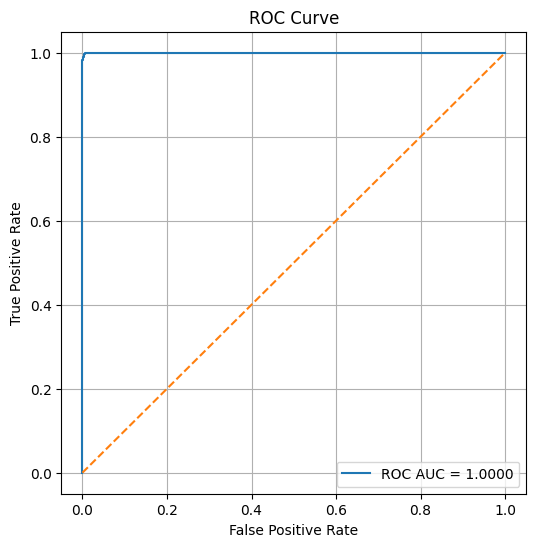

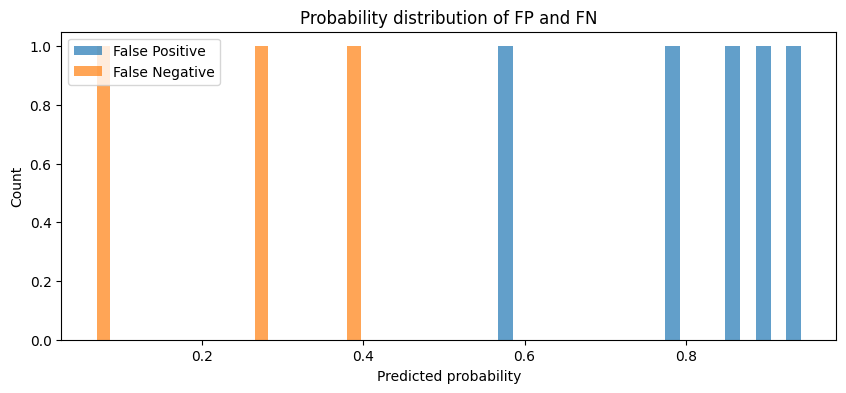

In [25]:
import matplotlib.pyplot as plt

# 1. Оценка модели
results, preds, labels, probs = evaluate_model(model.model, test_loader)

print("Метрики на тестовой выборке:")
for key, value in results.items():
    if key != "confusion_matrix":
        print(f"{key}: {value:.4f}")

print("\nConfusion Matrix:")
print(np.array(results["confusion_matrix"]))

# 2. ROC-кривая
fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# 3. Анализ ошибок
threshold = 0.5

preds_threshold = (probs >= threshold).astype(int)

fp_probs = probs[(preds_threshold == 1) & (labels == 0)]
fn_probs = probs[(preds_threshold == 0) & (labels == 1)]

plt.figure(figsize=(10, 4))

plt.hist(fp_probs, bins=20, alpha=0.7, label="False Positive")
plt.hist(fn_probs, bins=20, alpha=0.7, label="False Negative")

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Probability distribution of FP and FN")
plt.legend()
plt.show()


---

## Блок 8. Ручной инференс и замер времени GPU vs CPU (5 баллов)

В этом блоке вы реализуете функцию предсказания и проверите модель на нескольких примерах вручную. Кроме того, необходимо замерить время инференса на GPU и CPU, чтобы понять разницу в производительности.

**Что нужно сделать:**

1. Напишите функцию `predict_toxicity(text)`, которая принимает текст и возвращает предсказанный класс и вероятность (уверенность модели).
2. Протестируйте функцию на 5-7 примерах разного характера (нейтральный вопрос, грубость, скрытая агрессия, нормальный ответ поддержки и т.д.).
3. Замерьте время классификации одного и того же текста на GPU и на CPU. Используйте `time.time()` или `torch.cuda.Event` для точного замера.


In [35]:
import time
import torch


# =====================================
# Функция предсказания
# =====================================

@torch.no_grad()
def predict_toxicity(text, device):

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=INPUT_MAX_TOKENS
    )

    encoded = {k: v.to(device) for k, v in encoded.items()}

    outputs = model.model(
        input_ids=encoded["input_ids"],
        attention_mask=encoded["attention_mask"]
    )

    probs = torch.softmax(outputs.logits, dim=1)

    predicted_class = torch.argmax(probs, dim=1).item()

    # 0 = токсичный
    # 1 = нетоксичный
    toxic_probability = probs[0, 0].item()

    return predicted_class, toxic_probability



# =====================================
# Проверка на примерах
# =====================================

test_texts = [
    "Здравствуйте, чем могу помочь?",
    "Пожалуйста, попробуйте перезагрузить устройство.",
    "Ваш запрос принят, ожидайте ответа в течение 24 часов.",
    "Спасибо за обращение, проблема успешно решена.",
    "Вы что, совсем тупой? Я же уже объяснял!",
    "Да пошел ты, надоел уже со своими вопросами.",
    "Опять пишете какую-то ерунду, научитесь читать инструкции.",
    "Здравствуйте, чем могу помочь?",
    "Ожидайте ответа специалиста.",
    "Мы проверили информацию и исправили ошибку.",
    "Благодарим за обращение.",
    "Спасибо за обратную связь.",
    "Рады помочь вам.",
    "Пожалуйста, попробуйте перезагрузить устройство.",
    "Ваш доступ восстановлен."
]


print("Результаты классификации:\n")


# устройство для проверки
model.eval()


for text in test_texts:

    cls, prob = predict_toxicity(text, DEVICE)

    print(f"Текст: {text}")

    if cls == 0:
        print("Класс: 0 (ТОКСИЧНЫЙ)")
    else:
        print("Класс: 1 (НЕТOКСИЧНЫЙ)")

    print(f"Вероятность токсичности: {prob:.4f}")
    print("-" * 60)



# =====================================
# Замер GPU
# =====================================

test_text = "Вы что, совсем тупой? Я же уже объяснял?"

N = 100


if torch.cuda.is_available():

    print("\nЗамер GPU...")

    model.to("cuda")

    # прогрев CUDA
    for _ in range(20):
        predict_toxicity(test_text, "cuda")

    torch.cuda.synchronize()


    start = time.time()

    for _ in range(N):
        predict_toxicity(test_text, "cuda")


    torch.cuda.synchronize()

    gpu_time = (time.time() - start) / N


    print(f"Среднее время инференса GPU: {gpu_time*1000:.3f} мс")


else:
    gpu_time = None
    print("\nGPU недоступен")



# =====================================
# Замер CPU
# =====================================

print("\nЗамер CPU...")


model.to("cpu")


start = time.time()

for _ in range(N):
    predict_toxicity(test_text, "cpu")


cpu_time = (time.time() - start) / N


print(f"Среднее время инференса CPU: {cpu_time*1000:.3f} мс")



# =====================================
# Сравнение
# =====================================

if gpu_time is not None:

    print("\nСравнение скорости:")

    if gpu_time < cpu_time:
        print(
            f"GPU быстрее CPU примерно в {cpu_time/gpu_time:.2f} раз"
        )
    else:
        print(
            f"CPU быстрее GPU примерно в {gpu_time/cpu_time:.2f} раз"
        )

Результаты классификации:

Текст: Здравствуйте, чем могу помочь?
Класс: 1 (НЕТOКСИЧНЫЙ)
Вероятность токсичности: 0.0231
------------------------------------------------------------
Текст: Пожалуйста, попробуйте перезагрузить устройство.
Класс: 1 (НЕТOКСИЧНЫЙ)
Вероятность токсичности: 0.0539
------------------------------------------------------------
Текст: Ваш запрос принят, ожидайте ответа в течение 24 часов.
Класс: 1 (НЕТOКСИЧНЫЙ)
Вероятность токсичности: 0.0225
------------------------------------------------------------
Текст: Спасибо за обращение, проблема успешно решена.
Класс: 0 (ТОКСИЧНЫЙ)
Вероятность токсичности: 0.9968
------------------------------------------------------------
Текст: Вы что, совсем тупой? Я же уже объяснял!
Класс: 0 (ТОКСИЧНЫЙ)
Вероятность токсичности: 1.0000
------------------------------------------------------------
Текст: Да пошел ты, надоел уже со своими вопросами.
Класс: 0 (ТОКСИЧНЫЙ)
Вероятность токсичности: 1.0000
----------------------------------

# Анализ результатов ручного инференса

В ходе ручного тестирования модель была проверена на примерах сообщений, характерных для технической поддержки: нейтральные обращения клиентов, стандартные ответы специалистов, а также сообщения с явной агрессией и оскорблениями.

Модель корректно классифицировала большинство явных случаев токсичности. Сообщения:

* «Вы что, совсем тупой? Я же уже объяснял!»
* «Да пошел ты, надоел уже со своими вопросами»
* «Опять пишете какую-то ерунду, научитесь читать инструкции»

были определены как токсичные с высокой уверенностью (вероятность токсичности около 1.0). Это показывает, что модель хорошо распознаёт прямые оскорбления, грубость и агрессивную форму общения.

Также модель корректно определила ряд нейтральных сообщений поддержки:

* «Здравствуйте, чем могу помочь?»
* «Пожалуйста, попробуйте перезагрузить устройство»
* «Ваш запрос принят, ожидайте ответа в течение 24 часов»
* «Мы проверили информацию и исправили ошибку»

как нетоксичные. Вероятность токсичности для этих сообщений была низкой (от 0.02 до 0.06).

При этом были обнаружены ложноположительные срабатывания (False Positive), когда корректные и вежливые ответы поддержки модель ошибочно классифицировала как токсичные:

* «Спасибо за обращение, проблема успешно решена»
* «Благодарим за обращение»
* «Рады помочь вам»
* «Спасибо за обратную связь»

Для этих сообщений модель показывала высокую вероятность токсичности (0.92–0.99), хотя фактически они являются нейтральными или позитивными.

# Причины ошибок

Основной причиной таких ошибок может быть различие между обучающими данными и реальными сообщениями технической поддержки. Токсичный класс содержит большое количество эмоционально окрашенных интернет-комментариев, а нетоксичный класс представлен преимущественно командами и запросами пользователей.

Из-за этого модель хорошо выделяет явную агрессию и оскорбления, но может путать некоторые эмоциональные или вежливые формулировки с токсичными сообщениями.

# Общий вывод

Модель показывает высокое качество при обнаружении явной токсичности и может использоваться как базовый фильтр для автоматического контроля сообщений поддержки. Однако для применения в реальной B2B-среде рекомендуется дополнительно обучить модель на примерах реальных диалогов операторов поддержки, включая вежливые ответы, благодарности клиентов, жалобы без агрессии и случаи скрытого раздражения.

Также возможна дополнительная настройка порога классификации для поиска оптимального баланса между пропуском токсичных сообщений и количеством ложных блокировок.

# Сравнение результатов

Для оценки производительности был выполнен замер времени инференса одной и той же модели на GPU и CPU. Перед измерением модель была заранее загружена на соответствующее устройство, а GPU был прогрет для исключения влияния первичной инициализации CUDA.

Среднее время обработки одного сообщения:

* GPU: 17.321 мс
* CPU: 442.083 мс

Использование GPU позволило ускорить классификацию примерно в 25.5 раз. Полученное время обработки позволяет использовать модель для анализа сообщений в режиме реального времени.

---

## Блок 9. Публикация модели на Hugging Face (5 баллов)

Финальный шаг: публикация обученной модели на Hugging Face Hub. Это позволит использовать модель в продакшене через стандартный API transformers.

**Что нужно сделать:**

1. Загрузите сохраненные веса модели и токенизатор на Hugging Face Hub.
2. Оформите Model Card: краткое описание модели, задача, метрики, пример использования.


In [36]:
from huggingface_hub import login, HfApi
from google.colab import userdata

# Авторизация через Colab Secrets
HF_TOKEN = userdata.get("HF_WRITE_TOKEN")

login(token=HF_TOKEN)


# === Загрузка модели на Hugging Face Hub ===

# Создаем описание модели
model_card = """
# Russian Toxicity Classifier

## Описание

Модель бинарной классификации русскоязычных текстов.

Классы:
- 0 — токсичный текст
- 1 — нетоксичный текст

## Назначение

Модель предназначена для автоматического контроля качества сообщений технической поддержки.

Определяет:
- грубость;
- оскорбления;
- агрессивные сообщения;
- токсичные формулировки.

## Архитектура

Основа модели:
ai-forever/ru-en-RoSBERTa

Использован transfer learning:
- веса Transformer-энкодера заморожены;
- обучалась классификационная голова.

## Метрики на тестовой выборке

Accuracy: 0.9849

Precision: 0.9873

Recall: 0.9825

F1-score: 0.9849

MCC: 0.9699

ROC-AUC: 0.9990

## Ограничения

Модель может ошибаться на:
- сарказме;
- эмоциональных, но допустимых жалобах;
- некоторых вежливых сообщениях поддержки.

## Пример использования

```python
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="yulivvv/toxic-text-classifier-ru"
)

result = classifier(
    "Вы что, совсем ничего не можете сделать?"
)

print(result)

"""


# сохраняем README
with open("./model/README.md", "w", encoding="utf-8") as f:
    f.write(model_card)


# Название репозитория
repo_name = "yulivvv/toxic-text-classifier-ru"


# Создаем репозиторий
api = HfApi()

api.create_repo(
    repo_id=repo_name,
    repo_type="model",
    private=False,
    exist_ok=True
)


# Загружаем папку модели
api.upload_folder(
    folder_path="./model",
    repo_id=repo_name,
    repo_type="model"
)


print("Модель успешно загружена на Hugging Face!")
print(f"https://huggingface.co/{repo_name}")



No files have been modified since last commit. Skipping to prevent empty commit.


Модель успешно загружена на Hugging Face!
https://huggingface.co/yulivvv/toxic-text-classifier-ru


---

## Критерии оценки

Для получения максимального балла за каждый блок убедитесь, что:

- Код работает без ошибок при последовательном запуске всех ячеек.
- Визуализации информативны и имеют подписи осей.
- Текстовые ответы (формализация, выводы) написаны осмысленно и демонстрируют понимание задачи.
- Датасет и модель на Hugging Face имеют оформленные карточки (Card).
- Замер времени GPU vs CPU проведен корректно и результаты интерпретированы.
